# 4 Deep Learning Models
Project AirTS-Forecast

Report Section 4 Deep Learning

Project WBS 6

Author: Tiago TOLOCZKO ROSS

## Description
Welcome to the ultimate report for the exploration of pollution data

In [1]:
# import matplotlib.pyplot as plt
# import pickle
from pathlib import Path
import pandas as pd
from pollution_environmental_data_merging import merge_environmental_and_pollution, analyze_feature_correlations
import PollutionDataAnalysis.pollution_DL_models_multivariate as mv
import PollutionDataAnalysis.pollution_DL_models_single_variable as sv
from PollutionDataAnalysis.pollution_model_comparison_raymonds_version import load_results, plot_sv_vs_mv_ablation, plot_mape_bar_chart, print_improvement_table
from PollutionDataAnalysis.pollution_DL_models_hyperparameter_search import run_optuna_search_loop , analyze_optuna_study


[!] Using CPU
[!] Using CPU


In [2]:
POLLUTION_FILE = "PollutionDataAnalysis/outputs/consolidated_pollutants.parquet"
WEATHER_PARQUET_SOURCE = "EnvironmentalDataAnalysis/Exported_Parquet_Data"
FINAL_OUTPUT_FILE = "PollutionDataAnalysis/outputs/rnn_multivariate_dataset.parquet"

PROJECT_DIRECTORY = r"C:\Users\Tiago\Documents - PC\UTTOP\Enseignements\M1.2\Projet AirTS - Forecast"
OUTPUT_PLOT_DIRECTORY = Path(PROJECT_DIRECTORY+r"\DL PLOTS")

letters = 'abcdefghijklmn'
STUDY_POLLUTANTS = ["NO2", "NOx", "O3", "PM10", "PM25"]
STUDY_MODELS = ["RNN", "LSTM", "Bi-LSTM", "GRU"]



In [3]:
DATA_PERIODICITY = "daily"

final_dataset = merge_environmental_and_pollution(
    pollution_parquet_path=POLLUTION_FILE,
    environmental_parquet_path=WEATHER_PARQUET_SOURCE,
    output_parquet_path=FINAL_OUTPUT_FILE,
    periodicity=DATA_PERIODICITY
)


INFO: Step 1: Loading Base Pollution Data (Periodicity: daily)...
INFO: Step 2: Iterating and Merging Environmental Data...
INFO: Appending environmental feature: d2m_environmental_timeseries.parquet
INFO: Appending environmental feature: fal_environmental_timeseries.parquet
INFO: Appending environmental feature: skt_environmental_timeseries.parquet
INFO: Appending environmental feature: sp_environmental_timeseries.parquet
INFO: Appending environmental feature: stl1_environmental_timeseries.parquet
INFO: Appending environmental feature: stl2_environmental_timeseries.parquet
INFO: Appending environmental feature: stl3_environmental_timeseries.parquet
INFO: Appending environmental feature: stl4_environmental_timeseries.parquet
INFO: Appending environmental feature: t2m_environmental_timeseries.parquet
INFO: Appending environmental feature: u10_environmental_timeseries.parquet
INFO: Appending environmental feature: v10_environmental_timeseries.parquet
INFO: Step 3: Saving final multivaria

### General Parameters

In [4]:
df = pd.read_parquet(FINAL_OUTPUT_FILE)

if "Timestamp" in df.columns:
    df = df.set_index("Timestamp")
elif "timestamp" in df.columns:
    df = df.set_index("timestamp")

df_daily = df.resample("D").mean().interpolate(method='linear')
df_daily = df_daily[:]
print(f"[✓] Loaded: {len(df_daily)} days")


[✓] Loaded: 1826 days


## Single variable prediction

### Optimal parameters research
A module for bayesian research of optimal parameters

N dim -> 2; 4; 6

Hidden dim -> 2^6; 2^7; 2^8

Batch size -> 2^4; 2^6; 2^7

Look back -> 15, 30; 45

Horizon -> 7, 14, 28

Learning Rate -> 10^-3, 10^-2, 10^-1

Colect statistics: MAPE; MAE and RMS, if possible also time

compare and evaluate the top 5 best configurations and do some linear models for the best theoretical configuration

In [5]:
CATEGORICAL_GRID = {
    "NUM_LAYERS": (2, 4, 6),
    "HIDDEN_DIM": (64, 128, 256),
    "BATCH_SIZE": (16, 64, 128),
    "LOOK_BACK": (15, 30, 45),
    "HORIZON": (7, 21, 28),
    "LEARNING_RATE": (0.001, 0.01, 0.1)
}
sv.config.EPOCHS=50
sv.config.PATIENCE=30

# Already done: NO2 (RNN and LSTM)
run_optuna_search_loop(
    architecture="SV",
    df_daily=df_daily,
    target_list=[STUDY_POLLUTANTS[0]],
    model_list=STUDY_MODELS[2:5],
    n_trials=1, # Keep low for testing
    research_dict=CATEGORICAL_GRID,
    categorical_study=True
)



INITIATING SV_Bi-LSTM_Optuna_NO2


[I 2026-05-22 08:17:27,163] Using an existing study with name 'SV_Bi-LSTM_Optuna_NO2' instead of creating a new one.



[>] Training Trial_108...


[I 2026-05-22 08:17:42,106] Trial 108 pruned. 


 [!] Trial pruned by Optuna at epoch 4.

[✓] SV_Bi-LSTM_Optuna_NO2 COMPLETE | Best MAPE: 32.42%
[✓] Appended best SV-Bi-LSTM params for NO2 to outputs\best_parameters.json


[I 2026-05-22 08:17:42,722] A new study created in RDB with name: SV_GRU_Optuna_NO2



INITIATING SV_GRU_Optuna_NO2

[>] Training Trial_0...


[W 2026-05-22 08:17:49,774] Trial 0 failed with parameters: {'NUM_LAYERS': 4, 'HIDDEN_DIM': 256, 'BATCH_SIZE': 16, 'LOOK_BACK': 15, 'HORIZON': 28, 'LEARNING_RATE': 0.001} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\Tiago\IdeaProjects\AirTS_Forecast\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Tiago\IdeaProjects\AirTS_Forecast\PollutionDataAnalysis\pollution_DL_models_hyperparameter_search.py", line 143, in <lambda>
    study.optimize(lambda trial: objective_sv(trial, df_daily, target_col, model_name, research_dict, categorical_study), n_trials=n_trials)
                                 ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Tiago\IdeaProjects\AirTS_Forecast\PollutionDataAnalysis\pollution_DL_models_hyperparameter_search.py", line 103, in objective_sv
    model, _, _ = sv.train_mod

In [ ]:
target_pollutant = "PM25"
analyze_optuna_study(study_name="SV_RNN_Optuna_NO2", architecture='sv', target_col='NO2', model_name='RNN')

INFO: [✓] Loaded Optuna JSON: best_parameters.json



TARGET: NO2
 [⚙] Injected Optimized Parameters for RNN

[>] Training RNN (NO2)...
 [!] Early stopping triggered at epoch 97.
 [✓] RNN Metrics: RMSE=6.11, MAE=4.88, MAPE=32.61%

 [⚙] Injected Optimized Parameters for LSTM

[>] Training LSTM (NO2)...
 [!] Early stopping triggered at epoch 59.
 [✓] LSTM Metrics: RMSE=6.11, MAE=4.97, MAPE=34.72%

 [⚙] Injected Optimized Parameters for Bi-LSTM

[>] Training Bi-LSTM (NO2)...
 [!] Early stopping triggered at epoch 61.
 [✓] Bi-LSTM Metrics: RMSE=6.10, MAE=4.85, MAPE=32.11%

 [-] No optimized params found for SV-GRU. Using defaults.

[>] Training GRU (NO2)...
 [!] Early stopping triggered at epoch 55.
 [✓] GRU Metrics: RMSE=6.13, MAE=4.94, MAPE=34.01%


TARGET: NOx
 [-] No optimized params found for SV-RNN. Using defaults.

[>] Training RNN (NOx)...
 [!] Early stopping triggered at epoch 69.
 [✓] RNN Metrics: RMSE=10.07, MAE=7.79, MAPE=32.08%

 [-] No optimized params found for SV-LSTM. Using defaults.

[>] Training LSTM (NOx)...



KeyboardInterrupt



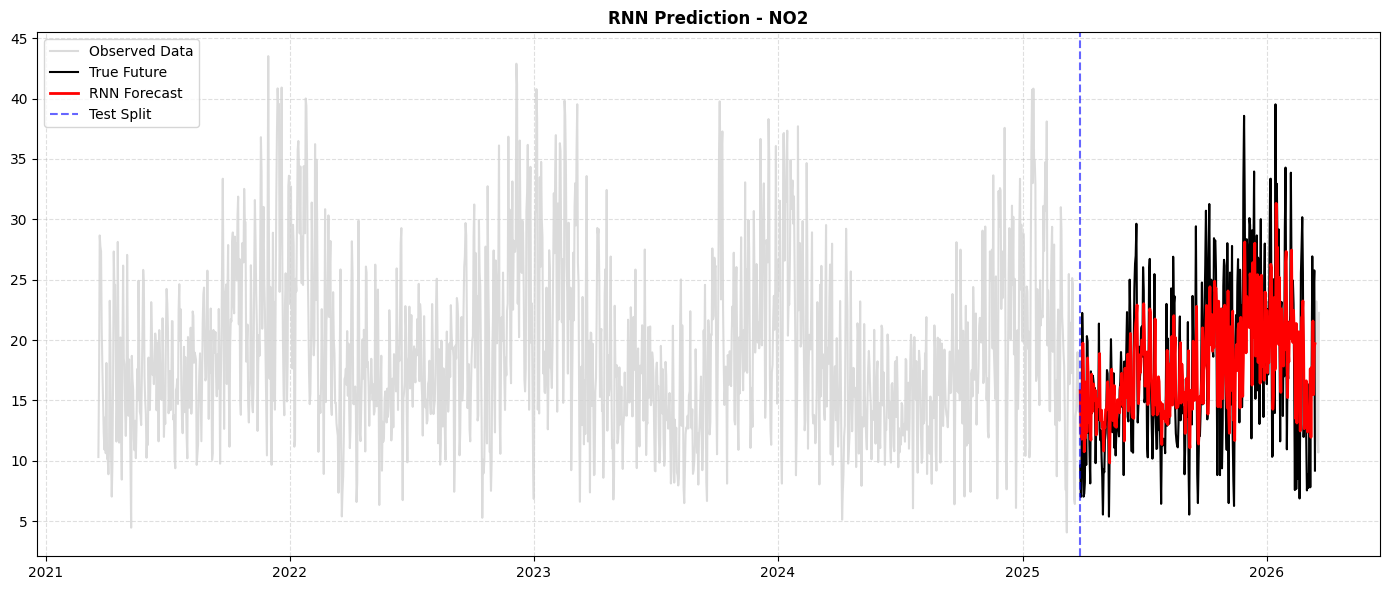

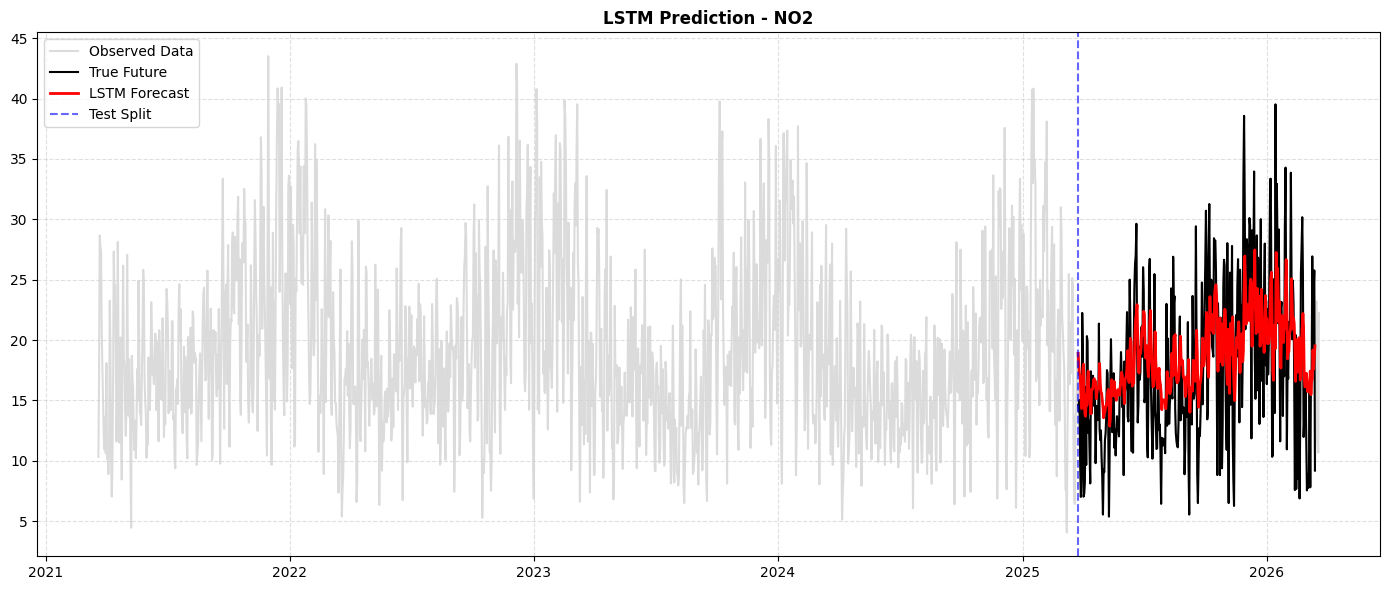

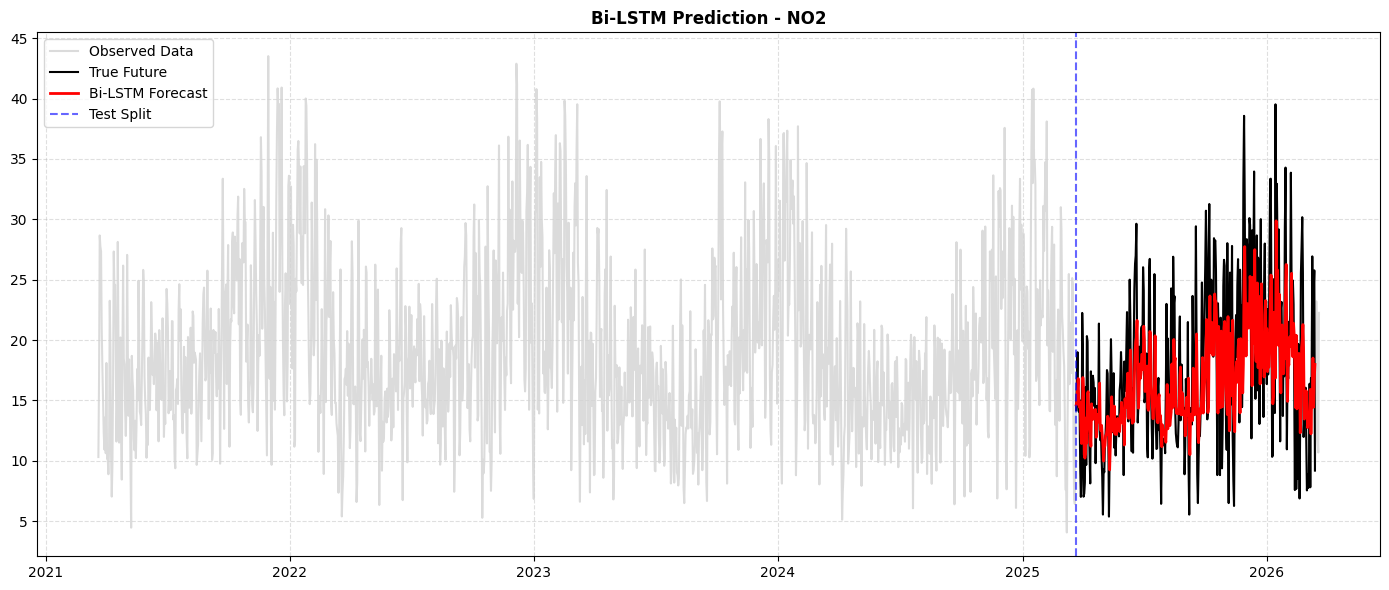

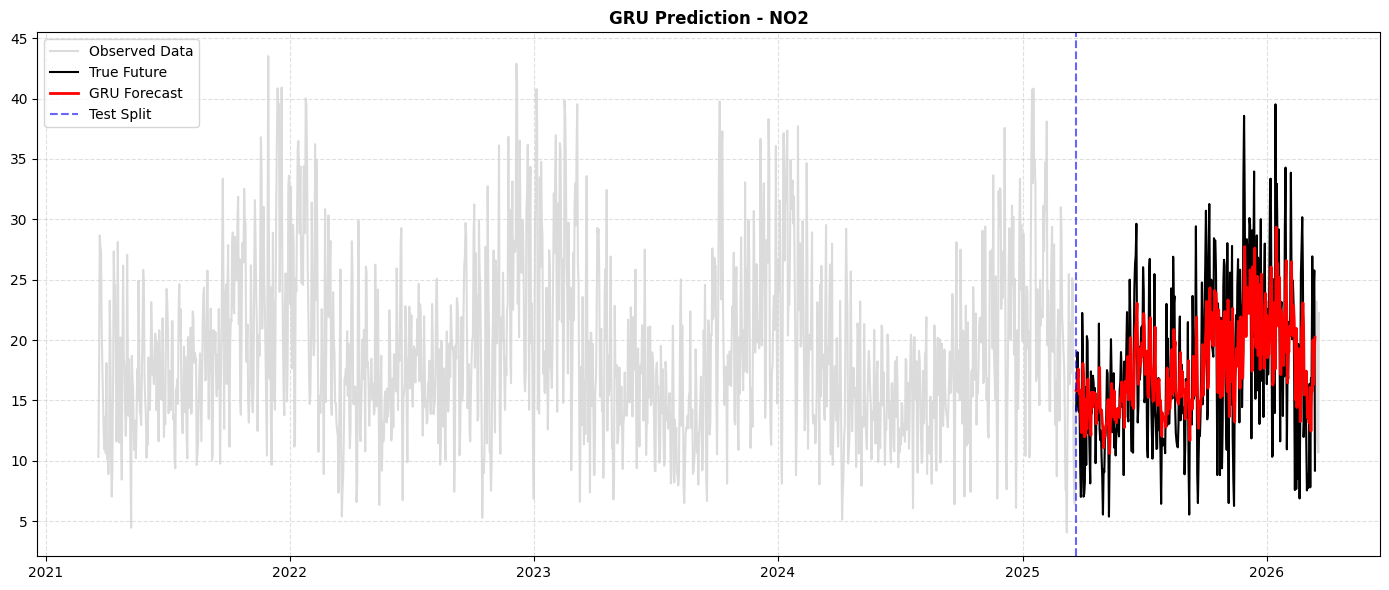

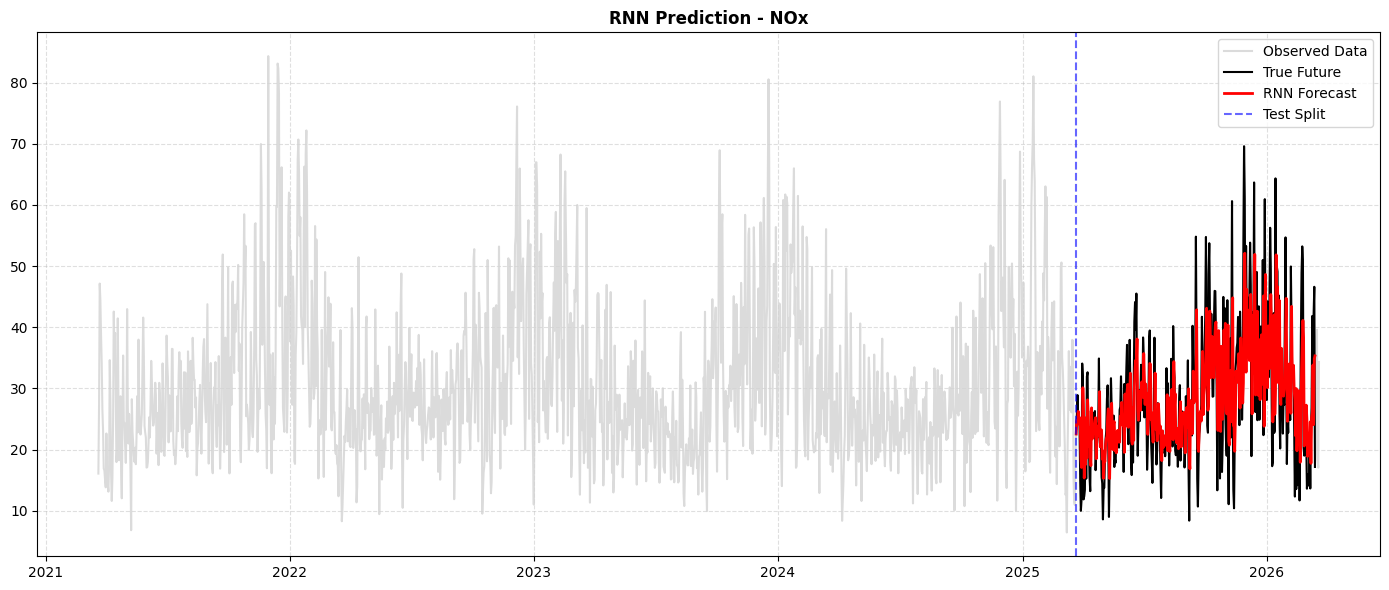

In [6]:
pollutants = ["NO2", "NOx", "O3", "PM10", "PM25"]

master_results = sv.model_looping(
    df_daily=df_daily,
    pollutants=tuple(STUDY_POLLUTANTS),
    optimized=True
)


## Multivariate data



FEATURE SELECTION: Spearman Correlation
[✓] Correlation heatmap saved to 'outputs/plots/correlation_heatmap.png'


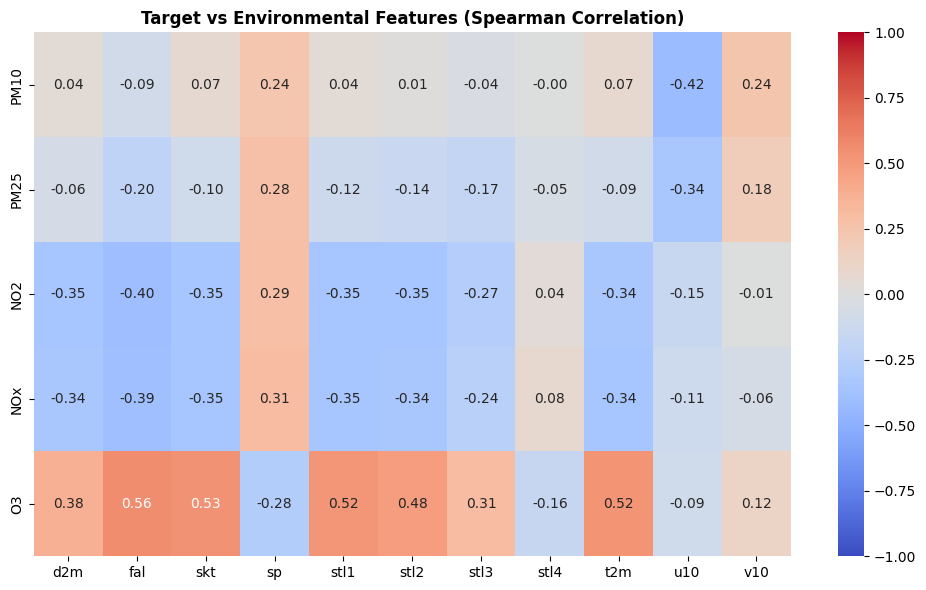


 Top 3 Predictors for PM10:
   -> u10: -0.416
   -> v10: 0.244
   -> sp: 0.235

 Top 3 Predictors for PM25:
   -> u10: -0.338
   -> sp: 0.279
   -> fal: -0.204

 Top 3 Predictors for NO2:
   -> fal: -0.399
   -> stl1: -0.350
   -> stl2: -0.348

 Top 3 Predictors for NOx:
   -> fal: -0.395
   -> skt: -0.347
   -> stl1: -0.347

 Top 3 Predictors for O3:
   -> fal: 0.562
   -> skt: 0.533
   -> t2m: 0.525


In [5]:
optimal_features_dict = {}
if not final_dataset.empty:
    targets = ["PM10", "PM25", "NO2", "NOx", "O3"]

    # Safely identify targets that exist in the dataframe
    valid_targets = [col for col in targets if col in final_dataset.columns]

    # Identify all columns that are NOT targets (these are our weather features)
    all_weather_features = [col for col in final_dataset.columns if col not in valid_targets]

    # --- Run Feature Selection ---
    if valid_targets and all_weather_features:
        title = "4.6 Correlation between weather variables and pollutants throughout the analysed period"
        parquet_path = OUTPUT_PLOT_DIRECTORY/Path(title+'.png')

        optimal_features_dict = analyze_feature_correlations(
            df=final_dataset,
            targets=valid_targets,
            features=all_weather_features,
            top_k=3,
            save_directory=parquet_path,
            method='spearman'
        )


### Hyperparameter research

In [ ]:
CATEGORICAL_GRID = {
    "NUM_LAYERS": (2, 4, 6),
    "HIDDEN_DIM": (64, 128, 256),
    "BATCH_SIZE": (16, 64, 128),
    "LOOK_BACK": (15, 30, 45 ,60),
    "HORIZON": (7, 21, 28),
    "LEARNING_RATE": (0.001, 0.01, 0.1)
}
mv.config.EPOCHS=50
mv.config.PATIENCE=30

run_optuna_search_loop(
    architecture="MV",
    df_daily=df_daily,
    target_list=STUDY_POLLUTANTS,
    model_list=STUDY_MODELS,
    feature_cols_map=optimal_features_dict,
    n_trials=10, # Keep low for testing
    research_dict=CATEGORICAL_GRID,
    categorical_study=True
)

In [ ]:
mv.model_looping(
    df_daily=df_daily,
    pollutant_features_map=optimal_features_dict,
    pollutants=tuple(STUDY_POLLUTANTS),
    optimized=True
)


## Model comparison

In [ ]:
deep_learning_single_variable = "outputs/sv_results.pkl"
classical_models = r"C:\Users\Tiago\IdeaProjects\AirTS_Forecast\PollutionDataAnalysis\outputs\classical_model_results.json"
mv_nn_fp = "outputs/mv_results.pkl"

benchmark = load_results(
    classical_filepath=classical_models,
    sv_nn_filepath=deep_learning_single_variable,
    mv_nn_filepath=mv_nn_fp
)

plot_mape_bar_chart(benchmark)
plot_sv_vs_mv_ablation(benchmark)
print_improvement_table(benchmark)